In [1]:
# 2026.05.19

In [2]:
# pip install tensorflow==2.15.0

In [3]:
import tensorflow as tf
import numpy as np

tf.__version__

'2.15.0'

In [4]:
a = tf.constant(10)
b = tf.constant(20)

c = a + b
d = (a + b).numpy()

print(type(c))
print(c)
print(type(d))
print(d)

d_numpy_to_tensor = tf.convert_to_tensor(d)
print(type(d_numpy_to_tensor))
print(d_numpy_to_tensor)

<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor(30, shape=(), dtype=int32)
<class 'numpy.int32'>
30
<class 'tensorflow.python.framework.ops.EagerTensor'>
tf.Tensor(30, shape=(), dtype=int32)


In [5]:
import tensorflow as tf

print("tensorflow version = ", tf.__version__)
print("============================================")

W = tf.Variable(tf.random.normal([1])) # 변수 정의
print("initial W = ", W.numpy())
print("============================================")

for step in range(2):
    W = W + 1.0
    print("step = ", step, ", W = ", W.numpy())

tensorflow version =  2.15.0
initial W =  [0.74879503]
step =  0 , W =  [1.748795]
step =  1 , W =  [2.748795]


# 케라스를 이용한 선형회귀 예제

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

In [7]:
x_data = np.array([1,2,3,4,5,6]) # x_data(입력값/독립변수)
t_data = np.array([3,4,5,6,7,8]) # t_data(정답값/종속변수)

In [8]:
model = Sequential()                     # 모델 생성 # 순차적으로 층을 쌓는 모델을 만들겠다는 선언
model.add(Flatten(input_shape=(1,)))     # 입력층    # 모델의 '첫 번째 입력층'을 정의
model.add(Dense(1, activation='linear')) # 출력층    # 모델의 핵심 계산을 담당하는 '출력층' 정의 # 회귀 //리니어 ,이중분류 //시그모이드  다중 분류 //소프트맥스
model.compile(optimizer=                 # optimizer = 경사하강법(sgd)를 이용하고, 
              SGD(learning_rate=1e-2),   # 학습률(learning_rate)를 = 10^-2
              loss='mse')                # loss 손실함수 = mse  // 분류 모델이기에 
model.summary()

# 입력 파라매터 1개와 출력 파라매터 1개 해서 총 2개라서 
# dense(Dense) 의 총 파라매터 개수가 2개로 나와있다.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 1)                 0         
                                                                 
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 예제 2

In [9]:
#  batch_size = 32 디폴트 값

hist = model.fit(x_data, t_data, epochs=1000, batch_size=32)

# 변수에는 손실값이 hist의 변수에 저장된다.

Epoch 1/1000

1/1 [==============================] - 0s 459ms/step - loss: 28.5711
Epoch 2/1000
1/1 [==============================] - 0s 4ms/step - loss: 13.5178
Epoch 3/1000
1/1 [==============================] - 0s 4ms/step - loss: 6.5486
Epoch 4/1000
1/1 [==============================] - 0s 4ms/step - loss: 3.3209
Epoch 5/1000
1/1 [==============================] - 0s 4ms/step - loss: 1.8249
Epoch 6/1000
1/1 [==============================] - 0s 7ms/step - loss: 1.1304
Epoch 7/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.8069
Epoch 8/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.6551
Epoch 9/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.5828
Epoch 10/1000
1/1 [==============================] - 0s 6ms/step - loss: 0.5473
Epoch 11/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.5289
Epoch 12/1000
1/1 [==============================] - 0s 6ms/step - loss: 0.5183
Epoch 13/1000
1/1 [=========================

In [10]:
hist.history

# 1000번 반복할 때마다 생성된 loss 값을 보여주고 있음.

{'loss': [28.57108497619629,
  13.517841339111328,
  6.548604488372803,
  3.3209025859832764,
  1.8249136209487915,
  1.1304272413253784,
  0.8069159388542175,
  0.6551175713539124,
  0.5828090310096741,
  0.5473054051399231,
  0.5288512706756592,
  0.5183024406433105,
  0.5114271640777588,
  0.5062670111656189,
  0.5019146800041199,
  0.4979507029056549,
  0.4941807687282562,
  0.4905144274234772,
  0.4869103729724884,
  0.4833488166332245,
  0.47982093691825867,
  0.4763220548629761,
  0.47285041213035583,
  0.4694046974182129,
  0.4659844636917114,
  0.46258947253227234,
  0.45921921730041504,
  0.4558734893798828,
  0.4525521695613861,
  0.4492551386356354,
  0.4459819793701172,
  0.44273272156715393,
  0.43950721621513367,
  0.4363051652908325,
  0.4331263303756714,
  0.42997097969055176,
  0.42683830857276917,
  0.42372867465019226,
  0.42064139246940613,
  0.41757670044898987,
  0.4145345389842987,
  0.41151440143585205,
  0.4085162878036499,
  0.40554001927375793,
  0.402585417

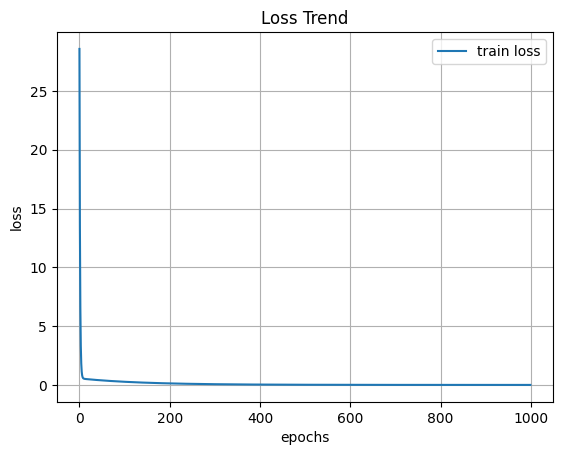

In [11]:
import matplotlib.pyplot as plt

plt.title("Loss Trend")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()

plt.plot(hist.history['loss'], label='train loss')
plt.legend(loc='best')

plt.show()

In [12]:
##### 위의 그래프가 계속 다르게 나오는 이유???

# 초기 파라매터값이 매번 다르기 때문?
# 경사하강법으로 찾아가는 과정도 다름..?

# 예제 3

In [13]:
result = model.predict(np.array([-3.1, 3.0, 3.5, 15.0, 20.1]))
result

1/1 [==============================] - 0s 123ms/step


array([[-1.1756651],
       [ 4.986866 ],
       [ 5.491992 ],
       [17.109879 ],
       [22.26216  ]], dtype=float32)

In [14]:
# 회귀모델인 경우 R^2 로 정확도를 확인한다.

In [15]:
# from sklearn.metrics import r2_score

# res = r2_score(정답, 예측값)
# print(res)

# stock_daily  예제 실습

In [16]:
# 주가 예측이니깐 주가 회귀모델롤 만들어보려고한다.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
import numpy as np

In [18]:
# 데이터 불러오기

import pandas as pd

data = pd.read_csv("stock_daily.csv")
data.head(2)

,Open,High,Low,Volume,Close
0,828.659973,833.450012,828.349976,1247700,831.659973
1,823.020020,828.070007,821.655029,1597800,828.070007


In [19]:
# 독립 변수와 종속변수 분할

xdata = data[['Open','High','Low','Volume']]
ydata = pd.DataFrame(data['Close'])

In [20]:
# 전처리 작업을 수행함

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# x,y 데이터의 개수가 달라서 따로따로 학습함

xdata_ss = sc.fit_transform(xdata)
ydata_ss = sc.fit_transform(ydata)

print(xdata_ss.shape, ydata_ss.shape)

(732, 4) (732, 1)


In [21]:
# 학습데이터와 검증 데이터를 나누는 작업이 필요하다.

In [22]:
xtrain = xdata_ss[:532, :]
xtest = xdata_ss[532:, :]

ytrain = ydata_ss[:532, :]
ytest = ydata_ss[532:, :]

# 주가는 시계열데이터이기 때문에 셔플로 섞지 않고 진행한다.

In [23]:
# 학습데이터와 검증 데이터의 구조 확인용
print( xtrain.shape, ytrain.shape, xtest.shape, ytest.shape)

(532, 4) (532, 1) (200, 4) (200, 1)


In [35]:
# 모델 설계
model = Sequential()
model.add(Flatten(input_shape=(4,)))      # 입력층  # Flatten : 2차원 구조를 1차원 구조로 변환시켜주는 것
model.add(Dense(16, activation='relu'))   # 은닉층
model.add(Dense(1, activation='linear'))  # 출력층  # 이진분류 : sigmoid, 다중분류: softmax
model.compile(optimizer=SGD(learning_rate=1e-2), loss='mse', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 4)                 0         
                                                                 
 dense_3 (Dense)             (None, 16)                80        
                                                                 
 dense_4 (Dense)             (None, 1)                 17        
                                                                 
Total params: 97 (388.00 Byte)
Trainable params: 97 (388.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
# 4*16 + 출력개수 16개 = 80
# 16*1 + 출력개수 1개 = 17

In [37]:
# 이제 모델을 만들었으니 학습을 시켜보자

In [38]:
hist = model.fit(xtrain, ytrain, epochs=1000, batch_size=32)

# 딥러닝으도 기본적으로 지도학습이기 때문에 학습을 시킬때 정답(ytrain)을 넣어서 학습시켜준다.

Epoch 1/1000

17/17 [==============================] - 1s 2ms/step - loss: 0.6140 - accuracy: 0.0000e+00
Epoch 2/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.1200 - accuracy: 0.0000e+00
Epoch 3/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0462 - accuracy: 0.0000e+00
Epoch 4/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0195 - accuracy: 0.0000e+00
Epoch 5/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0099 - accuracy: 0.0000e+00
Epoch 6/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0065 - accuracy: 0.0000e+00
Epoch 7/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0053 - accuracy: 0.0000e+00
Epoch 8/1000
17/17 [==============================] - 0s 1ms/step - loss: 0.0049 - accuracy: 0.0000e+00
Epoch 9/1000
17/17 [==============================] - 0s 2ms/step - loss: 0.0047 - accuracy: 0.0000e+00
Epoch 10/1000
17/17 [==============================] - 0s 2ms/s

In [39]:
hist.history

{'loss': [0.6140454411506653,
  0.11996746808290482,
  0.046193432062864304,
  0.01949211023747921,
  0.00986318476498127,
  0.006499404087662697,
  0.00533008249476552,
  0.004911176860332489,
  0.0047387550584971905,
  0.004656845238059759,
  0.004599402658641338,
  0.004543453920632601,
  0.00452034454792738,
  0.0044708894565701485,
  0.004419976379722357,
  0.004406173247843981,
  0.004394360352307558,
  0.004341627471148968,
  0.0043099066242575645,
  0.004278012551367283,
  0.004246523603796959,
  0.004208653699606657,
  0.004198105074465275,
  0.00417842622846365,
  0.004160060081630945,
  0.004128535743802786,
  0.004102081060409546,
  0.004076697397977114,
  0.004079394042491913,
  0.004042215645313263,
  0.004022466484457254,
  0.003992612008005381,
  0.0039632064290344715,
  0.003957798238843679,
  0.003942936658859253,
  0.003930481616407633,
  0.003911391366273165,
  0.003869668347761035,
  0.0038534433115273714,
  0.0038564044516533613,
  0.0038395363371819258,
  0.00381

In [40]:
pred = model.predict(xtest)
print(pred)

7/7 [==============================] - 0s 2ms/step
[[-1.423192  ]
 [-1.4507374 ]
 [-1.4033352 ]
 [-1.3044975 ]
 [-1.2406685 ]
 [-1.1823783 ]
 [-1.1624041 ]
 [-1.1689779 ]
 [-1.1457119 ]
 [-1.1610208 ]
 [-1.1168667 ]
 [-1.1773784 ]
 [-1.2607145 ]
 [-1.3199024 ]
 [-1.3294622 ]
 [-1.4440928 ]
 [-1.3284051 ]
 [-1.2380304 ]
 [-1.2243447 ]
 [-1.1792117 ]
 [-1.1408086 ]
 [-1.2100834 ]
 [-1.1897132 ]
 [-1.155061  ]
 [-1.1444011 ]
 [-1.1466314 ]
 [-1.1404645 ]
 [-1.0843741 ]
 [-1.0650485 ]
 [-1.0743793 ]
 [-1.0766845 ]
 [-1.0887756 ]
 [-1.0674354 ]
 [-1.1548688 ]
 [-1.1195099 ]
 [-1.0941379 ]
 [-1.0517116 ]
 [-1.0166595 ]
 [-0.98889816]
 [-0.98330915]
 [-0.9637915 ]
 [-1.0347475 ]
 [-1.0262818 ]
 [-1.0248038 ]
 [-0.92162   ]
 [-0.9468393 ]
 [-0.92372215]
 [-0.90215564]
 [-0.9818198 ]
 [-0.9728819 ]
 [-1.0291252 ]
 [-1.080253  ]
 [-1.043151  ]
 [-1.0520916 ]
 [-1.1303507 ]
 [-1.2173162 ]
 [-1.3146333 ]
 [-1.1600857 ]
 [-1.2287686 ]
 [-1.1491336 ]
 [-1.0549225 ]
 [-1.0045444 ]
 [-0.8675686 ]
 [-0

In [41]:
from sklearn.metrics import r2_score

res = r2_score(ytest, pred)
print(res)

0.9366841381570501


In [42]:
# 이걸 이제 시각화 해보자

Evaluate : 0.003741232786992337


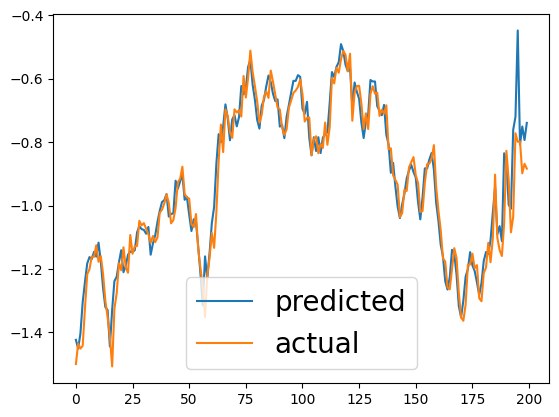

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(pred, label = 'predicted')
plt.plot(ytest,label = 'actual')
plt.legend(prop={'size':20})

print("Evaluate : {}".format(np.average((pred - ytest)**2)))

In [44]:
model.evaluate(xtest, ytest)

7/7 [==============================] - 0s 1ms/step - loss: 0.0037 - accuracy: 0.0000e+00


[0.003741233143955469, 0.0]